# Training Verification: Edge Hybrid Transformer
From-scratch training on character-level text. Verifies the hybrid attention architecture converges.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, math, time, os
import matplotlib.pyplot as plt

In [2]:
def linear_attn_seq(q, k, v, decay=0.99, eps=1e-6):
    B, H, T, D = q.shape
    qf, kf, vf = F.elu(q)+1, F.elu(k)+1, F.elu(v)+1
    S = torch.zeros(B, H, D, D, device=q.device)
    z = torch.zeros(B, H, D, device=q.device)
    outs = []
    for i in range(T):
        S = decay * S + kf[:,:,i:i+1].transpose(-2,-1) @ vf[:,:,i:i+1]
        z = decay * z + kf[:,:,i]
        out = (qf[:,:,i:i+1] @ S) / (qf[:,:,i:i+1] @ z.unsqueeze(-1)).clamp(min=eps)
        outs.append(out)
    return torch.cat(outs, -2)

class RoPE(nn.Module):
    def __init__(self, dim, base=10000.0):
        super().__init__()
        inv_freq = 1.0/(base**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq', inv_freq)
    def forward(self, x, offset=0):
        t = torch.arange(offset, offset+x.shape[-2], device=x.device).type_as(self.inv_freq)
        freqs = t.unsqueeze(-1) @ self.inv_freq.unsqueeze(0)
        return torch.cat([freqs, freqs], -1)
def apply_rope(x, emb):
    s = x.shape[-1]//2
    xc = torch.view_as_complex(x.reshape(*x.shape[:-1],s,2).contiguous())
    ec = torch.view_as_complex(emb.reshape(*emb.shape[:-1],s,2).contiguous())
    return torch.view_as_real(xc*ec).reshape(*x.shape[:-1],-1)

In [3]:
class EdgeTransformer(nn.Module):
    def __init__(self, dim=256, hd=64, nh=4, v=65):
        super().__init__()
        self.dim, self.hd, self.nh = dim, hd, nh
        self.embed = nn.Embedding(v, dim)
        self.rope_m = RoPE(hd)
        self.lm_head = nn.Linear(dim, v, 0)
        self.norm1 = nn.LayerNorm(dim)
        self.csa_k = nn.Linear(dim, hd, 0); self.csa_v = nn.Linear(dim, hd, 0)
        self.csa_q = nn.Linear(dim, hd, 0); self.csa_o = nn.Linear(hd, dim, 0)
        self.hca_k = nn.Linear(dim, hd, 0); self.hca_v = nn.Linear(dim, hd, 0)
        self.hca_q = nn.Linear(dim, hd, 0); self.hca_o = nn.Linear(hd, dim, 0)
        self.swa_q = nn.Linear(dim, dim, 0); self.swa_k = nn.Linear(dim, dim, 0)
        self.swa_v = nn.Linear(dim, dim, 0); self.swa_o = nn.Linear(dim, dim, 0)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
        self.gate = nn.Parameter(torch.ones(3))
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0.0, 0.02)
            if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, x):
        B, T = x.shape
        h = self.norm1(self.embed(x))
        qc = self.csa_q(h).view(B,T,1,self.hd).transpose(1,2)
        kc = self.csa_k(h).view(B,T,1,self.hd).transpose(1,2)
        vc = self.csa_v(h).view(B,T,1,self.hd).transpose(1,2)
        oc = self.csa_o(linear_attn_seq(qc,kc,vc,0.99).squeeze(1))
        qh = self.hca_q(h).view(B,T,1,self.hd).transpose(1,2)
        kh = self.hca_k(h).view(B,T,1,self.hd).transpose(1,2)
        vh = self.hca_v(h).view(B,T,1,self.hd).transpose(1,2)
        oh = self.hca_o(linear_attn_seq(qh,kh,vh,0.999).squeeze(1))
        qs = self.swa_q(h).view(B,T,self.nh,self.hd).transpose(1,2)
        ks = self.swa_k(h).view(B,T,self.nh,self.hd).transpose(1,2)
        vs = self.swa_v(h).view(B,T,self.nh,self.hd).transpose(1,2)
        emb = self.rope_m(ks); ks = apply_rope(ks, emb); qs = apply_rope(qs, emb)
        os_ = F.scaled_dot_product_attention(qs, ks, vs, is_causal=True)
        os_ = self.swa_o(os_.transpose(1,2).reshape(B,T,-1))
        g = F.softmax(self.gate, 0)
        h = h + g[0]*oc + g[1]*oh + g[2]*os_
        h = h + self.ffn(self.norm2(h))
        return self.lm_head(h)

In [4]:
path = os.path.expanduser('~/tiny.txt')
if not os.path.exists(path):
    with open(path, 'w') as f:
        f.write(('ROMEO: But soft what light through yonder window breaks '
                 'JULIET: O Romeo Romeo wherefore art thou Romeo '
                 'MERCUTIO: I am hurt a plague o both your houses ') * 3000)
with open(path, 'r') as f: text = f.read()
chars = sorted(list(set(text))); v = len(chars)
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for i,c in enumerate(chars)}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n1 = int(0.9 * len(data))
train_data, val_data = data[:n1], data[n1:]
print(f"Vocab: {v}, Train: {len(train_data):,}, Val: {len(val_data):,}")
def get_batch(data, sl=128, bs=8):
    ix = torch.randint(len(data)-sl-1, (bs,))
    x = torch.stack([data[i:i+sl] for i in ix])
    y = torch.stack([data[i+1:i+sl+1] for i in ix])
    return x, y

Vocab: 41, Train: 577,800, Val: 64,200


In [5]:
m = EdgeTransformer(dim=256, hd=64, nh=4, v=v)
print(f"Params: {sum(p.numel() for p in m.parameters()):,}")
opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
steps = 500; tl, vl = [], []; t0 = time.time()
for step in range(steps):
    m.train(); x, y = get_batch(train_data, 128, 4)
    loss = F.cross_entropy(m(x).reshape(-1, v), y.reshape(-1))
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
    if step % 50 == 0:
        m.eval()
        with torch.no_grad():
            xv, yv = get_batch(val_data, 128, 4)
            lv = F.cross_entropy(m(xv).reshape(-1, v), yv.reshape(-1))
        tl.append(loss.item()); vl.append(lv.item())
        print(f"step {step:>4} | train {loss.item():.4f} | val {lv.item():.4f} | {time.time()-t0:.1f}s")

Params: 940,803


step    0 | train 3.7946 | val 3.6731 | 0.7s


step   50 | train 1.4255 | val 1.4204 | 26.3s


step  100 | train 1.1520 | val 1.1563 | 54.0s


step  150 | train 1.1651 | val 1.1183 | 82.5s


...

step  250 | train 0.8038 | val 0.7798 | 136.8s


step  300 | train 0.8049 | val 0.7869 | 161.4s


step  350 | train 0.6982 | val 0.6118 | 188.2s


step  400 | train 0.6382 | val 0.6719 | 218.0s


step  450 | train 0.5953 | val 0.5692 | 246.1s


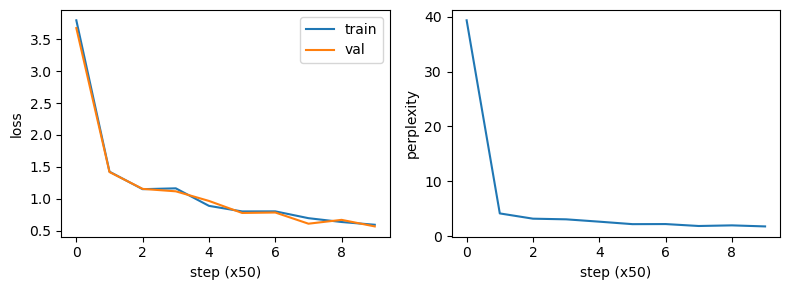

Final val loss: 0.5692, perplexity: 1.77


In [6]:
plt.figure(figsize=(8,3))
plt.subplot(121); plt.plot(tl, label='train'); plt.plot(vl, label='val')
plt.xlabel('step (x50)'); plt.ylabel('loss'); plt.legend()
plt.subplot(122); plt.plot([math.exp(l) for l in vl])
plt.xlabel('step (x50)'); plt.ylabel('perplexity')
plt.tight_layout(); plt.show()
print(f"Final val loss: {vl[-1]:.4f}, perplexity: {math.exp(vl[-1]):.2f}")